# Textual Contextual Bandits with Moderation Data


---

## Problem setting

You are supposed to design a moderation decision policy for user-generated text. For each post, the system must choose one action:

| Action id | Action | Operational meaning |
|---:|---|---|
| 0 | `allow` | publish immediately |
| 1 | `review` | route to human moderation |
| 2 | `block` | automatically remove |

You only observe the reward of the action you chose. This is contextual bandit feedback, not supervised full-information learning.

---
## Important note on running

This notebook requires internet access the first time it downloads the Hugging Face datasets. After caching, it can be rerun offline on the same machine.

Install dependencies:

```bash
pip install numpy pandas matplotlib torch datasets tqdm
```


In [1]:
!pip -q install datasets

In [2]:
import math
import re
import hashlib
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Tuple
from pathlib import Path
import urllib.request
import time
import os

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

try:
    from datasets import load_dataset
except Exception:
    load_dataset = None

SEED = 17

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
warnings.filterwarnings("ignore", category=UserWarning)

torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PyTorch CPU threads:", torch.get_num_threads())

ACTIONS = ["allow", "review", "block"]
ALLOW, REVIEW, BLOCK = 0, 1, 2
N_ACTIONS = len(ACTIONS)


Device: cuda
PyTorch CPU threads: 2


In [4]:
@dataclass
class Config:
    base_dataset_name: str = "cardiffnlp/tweet_eval"

    # Dataset sizes
    n_logged: int = 6000
    n_eval: int = 2000
    n_ood: int = 2000
    ope_fraction: float = 0.25

    # Hashing vectorizer
    hash_dim: int = 128
    min_token_len: int = 2

    # Neural models
    hidden: int = 64
    dropout_p: float = 0.20
    batch_size: int = 256
    reward_epochs: int = 8
    ensemble_epochs: int = 4
    risk_epochs: int = 8
    lr: float = 1e-3
    weight_decay: float = 1e-4

    # Logging policy
    behavior_temperature: float = 0.75
    behavior_uniform_mix: float = 0.15

    # Fixed policies
    epsilon: float = 0.10
    ensemble_size: int = 5
    mc_samples: int = 12

    # Safe exploration
    unsafe_threshold: float = 0.35
    extreme_unsafe_threshold: float = 0.42
    safety_margin: float = 0.15

    # LinUCB / NeuralUCB
    linucb_alpha: float = 0.60
    linucb_l2: float = 1.0
    neuralucb_alpha: float = 0.50

    # OPE uncertainty
    ope_bootstrap_samples: int = 200

cfg = Config()
cfg


Config(base_dataset_name='cardiffnlp/tweet_eval', n_logged=6000, n_eval=2000, n_ood=2000, ope_fraction=0.25, hash_dim=128, min_token_len=2, hidden=64, dropout_p=0.2, batch_size=256, reward_epochs=8, ensemble_epochs=4, risk_epochs=8, lr=0.001, weight_decay=0.0001, behavior_temperature=0.75, behavior_uniform_mix=0.15, epsilon=0.1, ensemble_size=5, mc_samples=12, unsafe_threshold=0.35, extreme_unsafe_threshold=0.42, safety_margin=0.15, linucb_alpha=0.6, linucb_l2=1.0, neuralucb_alpha=0.5, ope_bootstrap_samples=200)

## 1. Real dataset loading
### Task 1

Run the loader and inspect examples.


In [5]:
CACHE_DIR = Path("./tweeteval_cache")
CACHE_DIR.mkdir(exist_ok=True)

TWEETEVAL_GITHUB_BASE = "https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets"

# GitHub uses val, while Hugging Face commonly calls this validation.
SPLIT_TO_GITHUB = {
    "train": "train",
    "validation": "val",
    "val": "val",
    "test": "test",
}

def _sample_or_all(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    if len(df) <= n:
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return df.sample(n=n, random_state=seed).reset_index(drop=True)

def _read_cached_csv(task: str, split: str) -> Optional[pd.DataFrame]:
    path = CACHE_DIR / f"tweeteval_{task}_{split}.csv"
    if path.exists():
        df = pd.read_csv(path)
        if {"text", "label"}.issubset(df.columns):
            df["label"] = df["label"].astype(int)
            df["source"] = f"local_cache/{path.name}"
            return df
    return None

def _write_cached_csv(df: pd.DataFrame, task: str, split: str) -> None:
    path = CACHE_DIR / f"tweeteval_{task}_{split}.csv"
    df[["text", "label", "source"]].to_csv(path, index=False)

def _download_text(url: str, timeout: int = 30, retries: int = 4) -> str:
    last_error = None
    for attempt in range(retries):
        try:
            req = urllib.request.Request(
                url,
                headers={
                    "User-Agent": "Mozilla/5.0 educational-notebook",
                    "Accept": "text/plain,*/*",
                },
            )
            with urllib.request.urlopen(req, timeout=timeout) as response:
                return response.read().decode("utf-8", errors="replace")
        except Exception as e:
            last_error = e
            sleep_s = min(2 ** attempt, 8)
            print(f"Download failed attempt {attempt+1}/{retries}: {url}\n  {type(e).__name__}: {e}\n  retrying in {sleep_s}s")
            time.sleep(sleep_s)
    raise RuntimeError(f"Could not download {url}: {last_error}")

def load_tweeteval_from_github(task: str, split: str) -> pd.DataFrame:
    """Load official TweetEval text/label files directly from GitHub raw.
    Labels are stored as a single whitespace-separated line in the official repo.
    Text files contain one tweet per line.
    """
    cached = _read_cached_csv(task, split)
    if cached is not None:
        return cached

    gh_split = SPLIT_TO_GITHUB[split]
    text_url = f"{TWEETEVAL_GITHUB_BASE}/{task}/{gh_split}_text.txt"
    label_url = f"{TWEETEVAL_GITHUB_BASE}/{task}/{gh_split}_labels.txt"

    print(f"Downloading TweetEval {task}/{split} from official GitHub raw files.")
    text_raw = _download_text(text_url)
    label_raw = _download_text(label_url)

    texts = [line.strip() for line in text_raw.splitlines()]
    labels = [int(x) for x in label_raw.split()]

    if len(texts) != len(labels):
        raise ValueError(
            f"Text/label length mismatch for {task}/{split}: "
            f"{len(texts)} texts vs {len(labels)} labels"
        )

    df = pd.DataFrame({"text": texts, "label": labels})
    df["label"] = df["label"].astype(int)
    df["source"] = f"github_raw/tweeteval/{task}/{split}"
    _write_cached_csv(df, task, split)
    return df

def load_tweeteval_from_hf(dataset_name: str, config_name: str, split: str) -> pd.DataFrame:
    if load_dataset is None:
        raise RuntimeError("datasets is not installed; skipping Hugging Face fallback.")
    ds = load_dataset(dataset_name, config_name, split=split)
    df = pd.DataFrame(ds)
    if "text" not in df.columns or "label" not in df.columns:
        raise ValueError(f"Expected text and label columns, got {df.columns.tolist()}")
    df = df[["text", "label"]].copy()
    df["label"] = df["label"].astype(int)
    df["source"] = f"huggingface/{dataset_name}/{config_name}/{split}"
    return df

def load_original_repo_memmap(task: str, split_hint: str = "train") -> pd.DataFrame:
    """Fallback for users who already ran the original repo's prepare_data.py.

    The original repo stores GPT-2 token ids and labels in hf_data/tweet_eval/{task}.
    This fallback creates pseudo-text from token ids so the rest of the notebook can
    still run without Hugging Face/GitHub. Prefer GitHub/HF because they preserve text.
    """
    possible_roots = [
        Path("hf_data") / "tweet_eval" / task,
        Path("./llm-bandit-main") / "hf_data" / "tweet_eval" / task,
        Path("../llm-bandit-main") / "hf_data" / "tweet_eval" / task,
        Path("/mnt/data/llm-bandit-main") / "hf_data" / "tweet_eval" / task,
    ]
    root = next((p for p in possible_roots if (p / "data_labels.bin").exists()), None)
    if root is None:
        raise FileNotFoundError(f"No original repo memmap found for task={task}")

    block_size = 64
    labels = np.memmap(root / "data_labels.bin", dtype=np.uint16, mode="r")
    text_ids = np.memmap(root / "data_text.bin", dtype=np.uint16, mode="r").reshape(-1, block_size)

    pseudo_texts = []
    for row in text_ids:
        toks = [f"tok_{int(x)}" for x in row if int(x) != 0]
        pseudo_texts.append(" ".join(toks[:80]))

    df = pd.DataFrame({"text": pseudo_texts, "label": labels.astype(int)})
    df["source"] = f"original_repo_memmap/{root}"
    return df

def load_real_tweeteval_task(task: str, split: str, cfg: Config) -> pd.DataFrame:
    """Robust loader that avoids Hugging Face unless needed."""
    try:
        return load_tweeteval_from_github(task, split)
    except Exception as github_error:
        print(f"GitHub raw loading failed for {task}/{split}: {type(github_error).__name__}: {github_error}")

    try:
        return load_tweeteval_from_hf(cfg.base_dataset_name, task, split)
    except Exception as hf_error:
        print(f"Hugging Face fallback failed for {task}/{split}: {type(hf_error).__name__}: {hf_error}")

    try:
        return load_original_repo_memmap(task, split)
    except Exception as memmap_error:
        raise RuntimeError(
            f"All real-data loading methods failed for TweetEval {task}/{split}.\n"
            f"Fix options:\n"
            f"  1. Re-run later; Hugging Face 429 usually clears.\n"
            f"  2. Ensure GitHub raw access is available.\n"
            f"  3. Manually place CSVs in ./tweeteval_cache/ named tweeteval_{task}_{split}.csv "
            f"with columns text,label.\n"
            f"  4. Run the original repo prepare_data.py --data {task} to create hf_data memmaps.\n"
            f"Last memmap error: {type(memmap_error).__name__}: {memmap_error}"
        )

def load_real_moderation_data(cfg: Config) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load real in-domain and out-of-domain moderation datasets robustly."""
    # In-domain offensive data.
    train = load_real_tweeteval_task("offensive", "train", cfg)
    validation = load_real_tweeteval_task("offensive", "validation", cfg)
    test = load_real_tweeteval_task("offensive", "test", cfg)
    eval_pool = pd.concat([validation, test], ignore_index=True)

    # OOD hate data.
    ood_validation = load_real_tweeteval_task("hate", "validation", cfg)
    ood_test = load_real_tweeteval_task("hate", "test", cfg)
    ood_pool = pd.concat([ood_validation, ood_test], ignore_index=True)

    logged = _sample_or_all(train, cfg.n_logged, SEED + 1)
    eval_df = _sample_or_all(eval_pool, cfg.n_eval, SEED + 2)
    ood_df = _sample_or_all(ood_pool, cfg.n_ood, SEED + 3)

    return logged, eval_df, ood_df

logged_raw, eval_raw, ood_raw = load_real_moderation_data(cfg)

print("Loaded real datasets:")
display(pd.DataFrame({
    "split": ["logged_train", "in_domain_eval", "ood_hate_eval"],
    "rows": [len(logged_raw), len(eval_raw), len(ood_raw)],
    "harmful_rate": [logged_raw.label.mean(), eval_raw.label.mean(), ood_raw.label.mean()],
    "source": [
        ", ".join(sorted(logged_raw.source.unique())),
        ", ".join(sorted(eval_raw.source.unique())),
        ", ".join(sorted(ood_raw.source.unique())),
    ],
}))

display(logged_raw.sample(min(10, len(logged_raw)), random_state=SEED))


Loaded real datasets:


,split,rows,harmful_rate,source
0,logged_train,6000,0.331167,github_raw/tweeteval/offensive/train
1,in_domain_eval,2000,0.317000,"github_raw/tweeteval/offensive/test, github_ra..."
2,ood_hate_eval,2000,0.424000,"github_raw/tweeteval/hate/test, github_raw/twe..."


,text,label,source
4503,@user Antifa thugs remind me of orcs if they a...,1,github_raw/tweeteval/offensive/train
1424,13/? BOOOM. The MAC telling the @user to pay...,0,github_raw/tweeteval/offensive/train
4414,@user That’s why conservatives are so afraid o...,0,github_raw/tweeteval/offensive/train
5914,@user You can’t pretend to care about women wh...,0,github_raw/tweeteval/offensive/train
3768,@user Diversity = Success? LMAO,0,github_raw/tweeteval/offensive/train
5729,@user And when did Breitbart become a reliable...,0,github_raw/tweeteval/offensive/train
1491,. @user @user @user Fake conservatives and the...,1,github_raw/tweeteval/offensive/train
3592,@user @user Insanity...just like the commies! ...,0,github_raw/tweeteval/offensive/train
4378,@user WHAT THE FUCK,1,github_raw/tweeteval/offensive/train
318,@user Strange how Gun Control never works Crim...,0,github_raw/tweeteval/offensive/train


## 2. Text diagnostics and severity proxy

 Real moderation costs often depend on severity, but `tweet_eval/offensive` only provides binary labels.

We therefore construct a **severity proxy** from text signals and the harmful label. This is not perfect and should be discussed critically. It is used only to define richer reward and regret for the bandit environment.


In [6]:
TOKEN_RE = re.compile(r"[A-Za-z_@#!']+")

MILD_RISK_TERMS = {
    "stupid", "idiot", "shut", "hate", "trash", "dumb", "fool", "sucks",
    "worst", "clown", "garbage", "nonsense", "awful", "pathetic"
}

def tokenize(text: str) -> List[str]:
    return TOKEN_RE.findall(str(text).lower())

def text_risk_score(text: str) -> float:
    """A simple lexical risk proxy in [0, 1]."""
    raw = str(text)
    toks = tokenize(raw)
    if not toks:
        return 0.0

    risky = sum(t in MILD_RISK_TERMS for t in toks)
    risky_density = risky / max(1, len(toks))
    exclamation_density = min(raw.count("!") / 4.0, 1.0)
    all_caps = sum(len(t) >= 3 and t.isupper() for t in raw.split()) / max(1, len(raw.split()))
    direct_address = float(any(t.startswith("@") for t in toks))
    negative_pattern = float(bool(re.search(
        r"\b(you|ur|u)\b.{0,18}\b(stupid|idiot|dumb|trash|pathetic)\b",
        raw.lower(),
    )))

    score = (
        0.55 * min(risky_density * 4.0, 1.0)
        + 0.12 * exclamation_density
        + 0.13 * min(all_caps * 3.0, 1.0)
        + 0.05 * direct_address
        + 0.15 * negative_pattern
    )
    return float(np.clip(score, 0.0, 1.0))

def severity_proxy(text: str, label: int) -> float:
    """Environment-only severity proxy in [0, 1]."""
    risk = text_risk_score(text)
    if int(label) == 1:
        return float(np.clip(0.45 + 0.55 * risk, 0.0, 1.0))
    return float(np.clip(0.15 * risk, 0.0, 1.0))

def add_text_diagnostics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["n_tokens"] = out["text"].map(lambda s: len(tokenize(s)))
    out["risk_score"] = out["text"].map(text_risk_score)
    out["severity"] = [
        severity_proxy(text, label)
        for text, label in zip(out["text"], out["label"])
    ]
    out["has_risk_term"] = out["text"].map(
        lambda s: any(t in MILD_RISK_TERMS for t in tokenize(s))
    )
    out["has_mention"] = out["text"].astype(str).str.contains("@", regex=False)
    out["many_exclamations"] = out["text"].astype(str).str.count("!").ge(3)
    out["is_short"] = out["n_tokens"].le(5)
    return out

logged_df = add_text_diagnostics(logged_raw)
eval_df = add_text_diagnostics(eval_raw)
ood_df = add_text_diagnostics(ood_raw)

display(pd.DataFrame({
    "split": ["logged", "in_domain_eval", "ood_hate_eval"],
    "harmful_rate": [logged_df.label.mean(), eval_df.label.mean(), ood_df.label.mean()],
    "mean_risk_score": [logged_df.risk_score.mean(), eval_df.risk_score.mean(), ood_df.risk_score.mean()],
    "mean_severity": [logged_df.severity.mean(), eval_df.severity.mean(), ood_df.severity.mean()],
}))

display(logged_df.groupby("label")[["n_tokens", "risk_score", "severity"]].mean())


,split,harmful_rate,mean_risk_score,mean_severity
0,logged,0.331167,0.073869,0.171529
1,in_domain_eval,0.317000,0.064050,0.161557
2,ood_hate_eval,0.424000,0.059772,0.210415


,n_tokens,risk_score,severity
label,,,
0,21.340892,0.067746,0.010162
1,23.652743,0.086235,0.497429


## 3. Reward, oracle, regret, and cost-sensitivity analysis

A moderation classifier predicts a label. A contextual bandit chooses an action.

This section defines three product cost profiles:

1. `balanced`: balanced platform policy.
2. `high_safety`: strict platform; allowing harmful content is extremely costly.
3. `free_expression`: blocking benign content is especially costly.

You must evaluate how the optimal action distribution changes under different cost profiles.

### Task 3

Implement:

- `expected_reward_for_action`
- `reward_table`
- `oracle_action_and_value`
- `expected_regret`
- cost-profile comparison


In [7]:
COST_PROFILES = {
    "balanced": {
        "benign_allow": 1.00,
        "benign_review": 0.30,
        "benign_block": -1.60,
        "harm_allow_base": -2.00,
        "harm_allow_severity": -2.20,
        "harm_review_base": 0.50,
        "harm_review_severity": 0.15,
        "harm_block_base": 0.10,
        "harm_block_severity": 0.90,
    },
    "high_safety": {
        "benign_allow": 0.85,
        "benign_review": 0.20,
        "benign_block": -1.10,
        "harm_allow_base": -3.20,
        "harm_allow_severity": -3.50,
        "harm_review_base": 0.20,
        "harm_review_severity": 0.30,
        "harm_block_base": 0.90,
        "harm_block_severity": 0.85,
    },
    "free_expression": {
        "benign_allow": 1.15,
        "benign_review": 0.15,
        "benign_block": -2.80,
        "harm_allow_base": -1.20,
        "harm_allow_severity": -1.40,
        "harm_review_base": 0.55,
        "harm_review_severity": 0.10,
        "harm_block_base": 0.05,
        "harm_block_severity": 0.65,
    },
}

ACTIVE_PROFILE = "balanced"

def expected_reward_for_action(
    label: int,
    severity: float,
    action: int,
    profile: str = ACTIVE_PROFILE,
) -> float:
    c = COST_PROFILES[profile]
    label = int(label)
    action = int(action)
    severity = float(np.clip(severity, 0.0, 1.0))

    if label == 0:
        return float([
            c["benign_allow"],
            c["benign_review"],
            c["benign_block"],
        ][action])

    if action == ALLOW:
        return float(c["harm_allow_base"] - c["harm_allow_severity"] * severity)
    if action == REVIEW:
        return float(c["harm_review_base"] + c["harm_review_severity"] * severity)
    if action == BLOCK:
        return float(c["harm_block_base"] + c["harm_block_severity"] * severity)
    raise ValueError(f"Unknown action id: {action}")

def sample_observed_reward(
    label: int,
    severity: float,
    action: int,
    rng: np.random.Generator,
    profile: str = ACTIVE_PROFILE,
    noise_std: float = 0.08,
) -> float:
    mean = expected_reward_for_action(label, severity, action, profile)
    return float(mean + rng.normal(0.0, noise_std))

def reward_table(df: pd.DataFrame, profile: str = ACTIVE_PROFILE) -> np.ndarray:
    labels = df["label"].to_numpy(dtype=int)
    severity = df["severity"].to_numpy(dtype=float)
    table = np.empty((len(df), N_ACTIONS), dtype=np.float64)
    for action in range(N_ACTIONS):
        table[:, action] = [
            expected_reward_for_action(y, s, action, profile)
            for y, s in zip(labels, severity)
        ]
    return table

def oracle_action_and_value(
    df: pd.DataFrame,
    profile: str = ACTIVE_PROFILE,
) -> Tuple[np.ndarray, np.ndarray]:
    table = reward_table(df, profile)
    actions = table.argmax(axis=1).astype(int)
    values = table[np.arange(len(df)), actions]
    return actions, values

def expected_regret(
    df: pd.DataFrame,
    actions: np.ndarray,
    profile: str = ACTIVE_PROFILE,
) -> np.ndarray:
    actions = np.asarray(actions, dtype=int)
    if actions.shape != (len(df),):
        raise ValueError(f"Expected actions shape {(len(df),)}, got {actions.shape}")
    table = reward_table(df, profile)
    return table.max(axis=1) - table[np.arange(len(df)), actions]

def summarize_oracle_by_profile(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    rows = []
    for profile in COST_PROFILES:
        actions, values = oracle_action_and_value(df, profile)
        row = {
            "split": split_name,
            "profile": profile,
            "oracle_value": float(values.mean()),
        }
        for action, name in enumerate(ACTIONS):
            row[f"{name}_rate"] = float(np.mean(actions == action))
        rows.append(row)
    return pd.DataFrame(rows)

oracle_profile_table = pd.concat([
    summarize_oracle_by_profile(logged_df, "logged"),
    summarize_oracle_by_profile(eval_df, "eval"),
    summarize_oracle_by_profile(ood_df, "ood_hate"),
], ignore_index=True)

display(oracle_profile_table)


,split,profile,oracle_value,allow_rate,review_rate,block_rate
0,logged,balanced,0.860646,0.668833,0.286667,0.044500
1,logged,high_safety,1.006580,0.668833,0.000000,0.331167
2,logged,free_expression,0.967773,0.668833,0.331167,0.000000
3,eval,balanced,0.865959,0.683000,0.288000,0.029000
4,eval,high_safety,0.997971,0.683000,0.000000,0.317000
5,eval,free_expression,0.975344,0.683000,0.317000,0.000000
6,ood_hate,balanced,0.820092,0.576000,0.376500,0.047500
7,ood_hate,high_safety,1.045826,0.576000,0.000000,0.424000
8,ood_hate,free_expression,0.916144,0.576000,0.424000,0.000000


## 4. Logged bandit data with propensities

We simulate a behavior policy that resembles a legacy moderation system. It uses text heuristics and randomization.

For each example it logs:

```text
x_i, a_i, r_i, p_i
```

where `p_i = behavior_policy(a_i | x_i)`.

### Task 4

Implement the behavior policy and generate logged bandit data.


In [8]:
def softmax(z: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    z = np.asarray(z, dtype=np.float64)
    if temperature <= 0:
        raise ValueError("temperature must be positive")
    scaled = z / temperature
    scaled -= scaled.max()
    exp_z = np.exp(scaled)
    return exp_z / exp_z.sum()

def behavior_action_probs(text: str, cfg: Config = cfg) -> np.ndarray:
    risk = text_risk_score(text)

    # Three genuine regions: allow at low risk, review around the middle,
    # and block at high risk.
    preferences = np.array([
        1.40 - 2.80 * risk,
        1.25 - 3.00 * abs(risk - 0.45),
        -0.30 + 2.80 * risk,
    ])
    probs = softmax(preferences, cfg.behavior_temperature)

    # Uniform mixing guarantees overlap/support for every action.
    mix = float(np.clip(cfg.behavior_uniform_mix, 0.0, 1.0))
    probs = (1.0 - mix) * probs + mix / N_ACTIONS
    return probs / probs.sum()

def make_logged_bandit_data(
    df: pd.DataFrame,
    cfg: Config,
    seed: int = SEED,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    out = df.copy().reset_index(drop=True)

    actions, propensities, rewards = [], [], []
    for row in out.itertuples(index=False):
        probs = behavior_action_probs(row.text, cfg)
        action = int(rng.choice(N_ACTIONS, p=probs))
        reward = sample_observed_reward(
            row.label, row.severity, action, rng, profile=ACTIVE_PROFILE
        )
        actions.append(action)
        propensities.append(float(probs[action]))
        rewards.append(reward)

    out["logged_action"] = np.asarray(actions, dtype=int)
    out["logged_action_name"] = [ACTIONS[a] for a in actions]
    out["propensity"] = np.asarray(propensities, dtype=float)
    out["reward"] = np.asarray(rewards, dtype=float)
    return out

def split_policy_train_and_ope(
    log: pd.DataFrame,
    ope_fraction: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if not 0.0 < ope_fraction < 1.0:
        raise ValueError("ope_fraction must lie in (0, 1)")
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(log))
    n_ope = int(round(ope_fraction * len(log)))
    ope_idx = order[:n_ope]
    train_idx = order[n_ope:]
    return (
        log.iloc[train_idx].reset_index(drop=True),
        log.iloc[ope_idx].reset_index(drop=True),
    )

bandit_log = make_logged_bandit_data(logged_df, cfg, seed=SEED + 10)
policy_train_log, ope_log = split_policy_train_and_ope(
    bandit_log, cfg.ope_fraction, seed=SEED + 11
)

display(bandit_log.head())
display(bandit_log["logged_action_name"].value_counts(normalize=True).rename("rate").to_frame())
display(bandit_log["propensity"].describe().to_frame())

split_summary = pd.DataFrame({
    "split": ["policy_train", "ope_holdout"],
    "rows": [len(policy_train_log), len(ope_log)],
    "harmful_rate": [policy_train_log.label.mean(), ope_log.label.mean()],
    "allow_rate": [
        np.mean(policy_train_log.logged_action == ALLOW),
        np.mean(ope_log.logged_action == ALLOW),
    ],
    "review_rate": [
        np.mean(policy_train_log.logged_action == REVIEW),
        np.mean(ope_log.logged_action == REVIEW),
    ],
    "block_rate": [
        np.mean(policy_train_log.logged_action == BLOCK),
        np.mean(ope_log.logged_action == BLOCK),
    ],
})
display(split_summary)

risk_grid = np.array([0.00, 0.25, 0.45, 0.70, 1.00])
preference_grid = np.column_stack([
    1.40 - 2.80 * risk_grid,
    1.25 - 3.00 * np.abs(risk_grid - 0.45),
    -0.30 + 2.80 * risk_grid,
])
prob_grid = np.array([
    (1.0 - cfg.behavior_uniform_mix)
    * softmax(pref, cfg.behavior_temperature)
    + cfg.behavior_uniform_mix / N_ACTIONS
    for pref in preference_grid
])
display(pd.DataFrame(prob_grid, columns=ACTIONS).assign(risk=risk_grid))


,text,label,source,n_tokens,risk_score,severity,has_risk_term,has_mention,many_exclamations,is_short,logged_action,logged_action_name,propensity,reward
0,"@user So funny, this was labeled as sensitive ...",1,github_raw/tweeteval/offensive/train,20,0.110000,0.510500,False,True,False,False,1,review,0.223474,0.638727
1,@user @user ...I happen to know of your waywar...,0,github_raw/tweeteval/offensive/train,48,0.058125,0.008719,False,True,False,False,0,allow,0.669476,0.913426
2,@user @user He/she deserves those tattoos. Hop...,0,github_raw/tweeteval/offensive/train,11,0.050000,0.007500,False,True,False,False,2,block,0.144817,-1.613453
3,@user But gun control,0,github_raw/tweeteval/offensive/train,4,0.050000,0.007500,False,True,False,True,0,allow,0.679727,1.089645
4,@user He is hurt and no one has checked on him!!!,1,github_raw/tweeteval/offensive/train,11,0.140000,0.527000,False,True,True,False,0,allow,0.551647,-0.942972


,rate
logged_action_name,
allow,0.639167
review,0.195167
block,0.165667


,propensity
count,6000.000000
mean,0.484843
std,0.232365
min,0.121113
25%,0.181680
50%,0.640435
75%,0.679727
max,0.736041


,split,rows,harmful_rate,allow_rate,review_rate,block_rate
0,policy_train,4500,0.333333,0.643111,0.187778,0.169111
1,ope_holdout,1500,0.324667,0.627333,0.217333,0.155333


,allow,review,block,risk
0,0.736041,0.142846,0.121113,0.00
1,0.376192,0.355155,0.268653,0.25
2,0.151466,0.495737,0.352797,0.45
3,0.084825,0.193119,0.722056,0.70
4,0.054568,0.067331,0.878101,1.00


## 5. Hashing text features
We are going to use a deteministic hashing vectorizer, which is weaker than larger models like GPT, yet is still handy with real text and supports the contextual-bandit methods.

### Task 5

Implement a hashing vectorizer.


In [9]:
def stable_hash(token: str, dim: int) -> int:
    digest = hashlib.blake2b(token.encode("utf-8"), digest_size=8).digest()
    return int.from_bytes(digest, byteorder="little", signed=False) % dim

def stable_sign(token: str) -> int:
    digest = hashlib.blake2b(("sign:" + token).encode("utf-8"), digest_size=1).digest()
    return 1 if (digest[0] & 1) == 0 else -1

def hashing_vectorize(
    texts: Iterable[str],
    dim: int = cfg.hash_dim,
    min_token_len: int = cfg.min_token_len,
) -> np.ndarray:
    texts = list(texts)
    X = np.zeros((len(texts), dim), dtype=np.float32)

    for i, text in enumerate(texts):
        tokens = [t for t in tokenize(text) if len(t) >= min_token_len]
        features = [f"uni={t}" for t in tokens]
        features += [f"bi={a}__{b}" for a, b in zip(tokens[:-1], tokens[1:])]

        for feat in features:
            X[i, stable_hash(feat, dim)] += stable_sign(feat)

    norms = np.linalg.norm(X, axis=1, keepdims=True)
    X /= np.maximum(norms, 1e-12)
    return X

X_train = hashing_vectorize(policy_train_log.text)
X_ope = hashing_vectorize(ope_log.text)
X_eval = hashing_vectorize(eval_df.text)
X_ood = hashing_vectorize(ood_df.text)

print("Feature shapes:")
print("  train:", X_train.shape)
print("  OPE:", X_ope.shape)
print("  eval:", X_eval.shape)
print("  OOD:", X_ood.shape)


Feature shapes:
  train: (4500, 128)
  OPE: (1500, 128)
  eval: (2000, 128)
  OOD: (2000, 128)


## 6. Neural reward model from bandit feedback

The reward model predicts one value per action:

```text
Q_theta(x) = [Q(x, allow), Q(x, review), Q(x, block)]
```

But the loss is only applied to the logged action:

```text
loss = (Q_theta(x, a_logged) - r_logged)^2
```

### Task 6

Implement the MLP reward model and chosen-action training loop.


In [10]:
class MLPRewardModel(nn.Module):
    def __init__(
        self,
        d_in: int,
        hidden: int,
        dropout_p: float,
        n_actions: int = N_ACTIONS,
    ):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )
        self.head = nn.Linear(hidden, n_actions)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encoder(x))

    def features(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

def train_reward_model(
    model: nn.Module,
    X: np.ndarray,
    actions: np.ndarray,
    rewards: np.ndarray,
    cfg: Config,
    epochs: int,
    sample_weights: Optional[np.ndarray] = None,
    verbose: bool = True,
) -> nn.Module:
    model = model.to(device)
    x_t = torch.as_tensor(X, dtype=torch.float32)
    a_t = torch.as_tensor(actions, dtype=torch.long)
    r_t = torch.as_tensor(rewards, dtype=torch.float32)

    if sample_weights is None:
        w_t = torch.ones(len(X), dtype=torch.float32)
    else:
        w = np.asarray(sample_weights, dtype=np.float32)
        w /= max(float(w.mean()), 1e-8)
        w_t = torch.as_tensor(w, dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(x_t, a_t, r_t, w_t),
        batch_size=cfg.batch_size,
        shuffle=True,
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    for epoch in range(epochs):
        model.train()
        total_loss, total_n = 0.0, 0
        for xb, ab, rb, wb in loader:
            xb = xb.to(device)
            ab = ab.to(device)
            rb = rb.to(device)
            wb = wb.to(device)

            pred = model(xb).gather(1, ab[:, None]).squeeze(1)
            loss = (wb * (pred - rb).pow(2)).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item()) * len(xb)
            total_n += len(xb)

        if verbose and (
            epoch == 0
            or (epoch + 1) % max(1, epochs // 4) == 0
            or epoch + 1 == epochs
        ):
            print(
                f"reward epoch {epoch + 1:02d}/{epochs}: "
                f"loss={total_loss / total_n:.4f}"
            )
    return model

@torch.no_grad()
def predict_q(
    model: nn.Module,
    X: np.ndarray,
    batch_size: int = 512,
    mc_dropout: bool = False,
) -> np.ndarray:
    was_training = model.training
    model.train(mc_dropout)
    outputs = []

    for start in range(0, len(X), batch_size):
        xb = torch.as_tensor(
            X[start:start + batch_size],
            dtype=torch.float32,
            device=device,
        )
        outputs.append(model(xb).cpu().numpy())

    model.train(was_training)
    return np.concatenate(outputs, axis=0) if outputs else np.empty((0, N_ACTIONS))

set_seed(SEED)
reward_model = MLPRewardModel(cfg.hash_dim, cfg.hidden, cfg.dropout_p)
reward_model = train_reward_model(
    reward_model,
    X_train,
    policy_train_log.logged_action.values,
    policy_train_log.reward.values,
    cfg,
    epochs=cfg.reward_epochs,
    verbose=True,
)

display(pd.DataFrame(predict_q(reward_model, X_eval[:5]), columns=ACTIONS))

q_eval_pred = predict_q(reward_model, X_eval)
q_eval_true = reward_table(eval_df)
reward_rmse = np.sqrt(np.mean((q_eval_pred - q_eval_true) ** 2, axis=0))
display(pd.DataFrame({
    "action": ACTIONS,
    "heldout_RMSE": reward_rmse,
}))


reward epoch 01/8: loss=0.9554
reward epoch 02/8: loss=0.8393
reward epoch 04/8: loss=0.7147
reward epoch 06/8: loss=0.6895
reward epoch 08/8: loss=0.6700


,allow,review,block
0,0.202457,0.339656,-0.651390
1,0.337372,0.374456,-0.795561
2,0.352492,0.370148,-0.786043
3,0.271317,0.368778,-0.779488
4,0.283808,0.341309,-0.854845


,action,heldout_RMSE
0,allow,0.886854
1,review,0.136178
2,block,0.997849


## 7. Risk model for safety and calibration

Safe exploration and calibration require an estimate of harmfulness probability.

This classifier is trained on the real dataset labels. In real deployment, labels may come from audits, human moderation, or a separate historical supervised dataset.

### Task 7

Implement a risk classifier and train it.

You will use this model later for:

- safe exploration constraints,
- calibration and reliability analysis,
- safety metrics.


In [11]:
class RiskClassifier(nn.Module):
    def __init__(self, d_in: int, hidden: int, dropout_p: float):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )
        self.head = nn.Linear(hidden, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encoder(x)).squeeze(-1)

def train_risk_classifier(
    model: nn.Module,
    X: np.ndarray,
    y: np.ndarray,
    cfg: Config,
    epochs: int,
) -> nn.Module:
    model = model.to(device)
    x_t = torch.as_tensor(X, dtype=torch.float32)
    y_t = torch.as_tensor(y, dtype=torch.float32)
    loader = DataLoader(
        TensorDataset(x_t, y_t),
        batch_size=cfg.batch_size,
        shuffle=True,
    )

    # Unweighted BCE preserves the original class prior and is more suitable
    # when sigmoid outputs are interpreted as probabilities.
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    for epoch in range(epochs):
        model.train()
        total_loss, total_n = 0.0, 0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            loss = criterion(model(xb), yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item()) * len(xb)
            total_n += len(xb)

        if (
            epoch == 0
            or (epoch + 1) % max(1, epochs // 4) == 0
            or epoch + 1 == epochs
        ):
            print(
                f"risk epoch {epoch + 1:02d}/{epochs}: "
                f"loss={total_loss / total_n:.4f}"
            )
    return model

@torch.no_grad()
def predict_risk(
    model: nn.Module,
    X: np.ndarray,
    batch_size: int = 512,
    mc_dropout: bool = False,
) -> np.ndarray:
    was_training = model.training
    model.train(mc_dropout)
    outputs = []

    for start in range(0, len(X), batch_size):
        xb = torch.as_tensor(
            X[start:start + batch_size],
            dtype=torch.float32,
            device=device,
        )
        outputs.append(torch.sigmoid(model(xb)).cpu().numpy())

    model.train(was_training)
    return np.concatenate(outputs) if outputs else np.empty(0)

set_seed(SEED + 100)
risk_model = RiskClassifier(cfg.hash_dim, cfg.hidden, cfg.dropout_p)
risk_model = train_risk_classifier(
    risk_model,
    X_train,
    policy_train_log.label.values,
    cfg,
    epochs=cfg.risk_epochs,
)

risk_eval = predict_risk(risk_model, X_eval)
risk_ood = predict_risk(risk_model, X_ood)

display(pd.DataFrame({
    "split": ["eval", "ood_hate"],
    "mean_predicted_risk": [risk_eval.mean(), risk_ood.mean()],
    "true_label_rate": [eval_df.label.mean(), ood_df.label.mean()],
}))


risk epoch 01/8: loss=0.6766
risk epoch 02/8: loss=0.6535
risk epoch 04/8: loss=0.6302
risk epoch 06/8: loss=0.6219
risk epoch 08/8: loss=0.6106


,split,mean_predicted_risk,true_label_rate
0,eval,0.331547,0.317
1,ood_hate,0.353392,0.424


## 8. Fixed policies from the reward model

Implement and evaluate:

1. Greedy reward model.
2. Epsilon-greedy reward model.
3. MC-dropout Thompson Sampling.
4. Bootstrapped ensemble Thompson Sampling.

### Task 8

Evaluate each policy on in-domain and OOD data.


In [12]:
def greedy_from_q(q: np.ndarray) -> np.ndarray:
    return np.asarray(q).argmax(axis=1).astype(int)

def deterministic_policy_probs(
    actions: np.ndarray,
    n_actions: int = N_ACTIONS,
) -> np.ndarray:
    actions = np.asarray(actions, dtype=int)
    if np.any((actions < 0) | (actions >= n_actions)):
        raise ValueError("actions contain an invalid action id")
    probs = np.zeros((len(actions), n_actions), dtype=np.float64)
    probs[np.arange(len(actions)), actions] = 1.0
    return probs

def sample_actions_from_probs(probs: np.ndarray, seed: int) -> np.ndarray:
    probs = np.asarray(probs, dtype=np.float64)
    if probs.ndim != 2 or probs.shape[1] != N_ACTIONS:
        raise ValueError("probs must have shape [n, n_actions]")
    if not np.allclose(probs.sum(axis=1), 1.0, atol=1e-6):
        raise ValueError("policy probabilities must sum to one")
    rng = np.random.default_rng(seed)
    return np.array([
        rng.choice(N_ACTIONS, p=row)
        for row in probs
    ], dtype=int)

def epsilon_greedy_from_q(
    q: np.ndarray,
    epsilon: float,
    seed: int,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    actions = greedy_from_q(q)
    explore = rng.random(len(actions)) < epsilon
    actions[explore] = rng.integers(
        0, N_ACTIONS, size=int(explore.sum())
    )
    return actions

def mc_dropout_q_samples(
    model: nn.Module,
    X: np.ndarray,
    n_samples: int,
    seed: int,
) -> np.ndarray:
    set_seed(seed)
    return np.stack([
        predict_q(model, X, mc_dropout=True)
        for _ in range(n_samples)
    ], axis=0)

def policy_probs_from_action_samples(
    action_samples: np.ndarray,
    n_actions: int = N_ACTIONS,
) -> np.ndarray:
    action_samples = np.asarray(action_samples, dtype=int)
    probs = np.stack([
        np.mean(action_samples == action, axis=0)
        for action in range(n_actions)
    ], axis=1)
    return probs

def dropout_policy_probs(
    model: nn.Module,
    X: np.ndarray,
    seed: int,
) -> np.ndarray:
    q_samples = mc_dropout_q_samples(
        model, X, cfg.mc_samples, seed
    )
    action_samples = q_samples.argmax(axis=2)
    return policy_probs_from_action_samples(action_samples)

def dropout_ts_policy(
    model: nn.Module,
    X: np.ndarray,
    seed: int,
) -> np.ndarray:
    probs = dropout_policy_probs(model, X, seed)
    return sample_actions_from_probs(probs, seed + 1)

def train_bootstrap_ensemble(
    X: np.ndarray,
    actions: np.ndarray,
    rewards: np.ndarray,
    cfg: Config,
    k: int,
    seed: int,
) -> List[nn.Module]:
    rng = np.random.default_rng(seed)
    models = []

    for j in range(k):
        idx = rng.integers(0, len(X), size=len(X))
        set_seed(seed + j + 1)
        model = MLPRewardModel(
            cfg.hash_dim, cfg.hidden, cfg.dropout_p
        )
        model = train_reward_model(
            model,
            X[idx],
            actions[idx],
            rewards[idx],
            cfg,
            epochs=cfg.ensemble_epochs,
            verbose=False,
        )
        models.append(model)
        print(f"trained bootstrap model {j + 1}/{k}")

    return models

def ensemble_policy_probs(
    models: List[nn.Module],
    X: np.ndarray,
) -> np.ndarray:
    if not models:
        raise ValueError("models must be nonempty")
    action_samples = np.stack([
        predict_q(model, X).argmax(axis=1)
        for model in models
    ], axis=0)
    return policy_probs_from_action_samples(action_samples)

def ensemble_ts_policy(
    models: List[nn.Module],
    X: np.ndarray,
    seed: int,
) -> np.ndarray:
    probs = ensemble_policy_probs(models, X)
    return sample_actions_from_probs(probs, seed)

def evaluate_action_vector(
    df: pd.DataFrame,
    actions: np.ndarray,
    name: str,
    profile: str = ACTIVE_PROFILE,
) -> Dict[str, float]:
    actions = np.asarray(actions, dtype=int)
    table = reward_table(df, profile)
    values = table[np.arange(len(df)), actions]
    regrets = expected_regret(df, actions, profile)
    labels = df.label.to_numpy(dtype=int)

    row = {
        "policy": name,
        "avg_value": float(values.mean()),
        "avg_regret": float(regrets.mean()),
        "harmful_allow_rate": (
            float(np.mean(actions[labels == 1] == ALLOW))
            if np.any(labels == 1) else np.nan
        ),
        "benign_block_rate": (
            float(np.mean(actions[labels == 0] == BLOCK))
            if np.any(labels == 0) else np.nan
        ),
    }
    for action, action_name in enumerate(ACTIONS):
        row[f"{action_name}_rate"] = float(np.mean(actions == action))
    return row

ensemble = train_bootstrap_ensemble(
    X_train,
    policy_train_log.logged_action.values,
    policy_train_log.reward.values,
    cfg,
    k=cfg.ensemble_size,
    seed=SEED + 200,
)

def evaluate_fixed_policies(
    df: pd.DataFrame,
    X: np.ndarray,
    title: str,
) -> pd.DataFrame:
    q = predict_q(reward_model, X)
    policies = {
        "oracle": oracle_action_and_value(df)[0],
        "greedy_mlp": greedy_from_q(q),
        f"epsilon_{cfg.epsilon:.2f}_mlp": epsilon_greedy_from_q(
            q, cfg.epsilon, SEED + 1
        ),
        "dropout_ts_mlp": dropout_ts_policy(
            reward_model, X, SEED + 2
        ),
        "ensemble_ts_mlp": ensemble_ts_policy(
            ensemble, X, SEED + 3
        ),
    }
    rows = [
        evaluate_action_vector(df, actions, name)
        for name, actions in policies.items()
    ]
    out = pd.DataFrame(rows).sort_values("avg_regret")
    print(title)
    display(out)
    return out

eval_results = evaluate_fixed_policies(
    eval_df, X_eval, "In-domain fixed-policy evaluation"
)
ood_results = evaluate_fixed_policies(
    ood_df, X_ood, "OOD hate fixed-policy evaluation"
)


trained bootstrap model 1/5
trained bootstrap model 2/5
trained bootstrap model 3/5
trained bootstrap model 4/5
trained bootstrap model 5/5
In-domain fixed-policy evaluation


,policy,avg_value,avg_regret,harmful_allow_rate,benign_block_rate,allow_rate,review_rate,block_rate
0,oracle,0.865959,0.000000,0.000000,0.000000,0.6830,0.2880,0.029
1,greedy_mlp,0.443640,0.422319,0.305994,0.000000,0.3845,0.6155,0.000
3,dropout_ts_mlp,0.433321,0.432638,0.317035,0.000000,0.3810,0.6190,0.000
4,ensemble_ts_mlp,0.408733,0.457226,0.134069,0.000000,0.1645,0.8355,0.000
2,epsilon_0.10_mlp,0.381913,0.484046,0.304416,0.040264,0.3700,0.5900,0.040


OOD hate fixed-policy evaluation


,policy,avg_value,avg_regret,harmful_allow_rate,benign_block_rate,allow_rate,review_rate,block_rate
0,oracle,0.820092,0.000000,0.000000,0.000000,0.5760,0.3765,0.0475
4,ensemble_ts_mlp,0.412569,0.407524,0.088443,0.000000,0.1130,0.8870,0.0000
1,greedy_mlp,0.378162,0.441930,0.220519,0.000000,0.2395,0.7605,0.0000
3,dropout_ts_mlp,0.368220,0.451872,0.250000,0.000000,0.2645,0.7355,0.0000
2,epsilon_0.10_mlp,0.335719,0.484373,0.220519,0.040799,0.2435,0.7165,0.0400


## 9. Safe exploration constraints


Naive exploration can randomly `allow` harmful content or randomly `block` benign content. In a real moderation system, exploration must be constrained.

We define a risk-aware action mask:

- if predicted harmfulness is below `unsafe_threshold`, all actions are allowed;
- if predicted harmfulness is above `unsafe_threshold`, `allow` is disallowed;
- if predicted harmfulness is above `extreme_unsafe_threshold`, only `review` and `block` are allowed, and `review` is preferred unless `block` has enough predicted advantage.

### Task 9

Implement safe action masking and safe versions of epsilon-greedy and Thompson Sampling.


In [13]:
def safe_action_mask(
    risk_probs: np.ndarray,
    unsafe_threshold: float = cfg.unsafe_threshold,
) -> np.ndarray:
    risk_probs = np.asarray(risk_probs, dtype=float)
    mask = np.ones((len(risk_probs), N_ACTIONS), dtype=bool)
    mask[risk_probs >= unsafe_threshold, ALLOW] = False
    return mask

def safe_feasible_mask(
    q: np.ndarray,
    risk_probs: np.ndarray,
    unsafe_threshold: float = cfg.unsafe_threshold,
    extreme_threshold: float = cfg.extreme_unsafe_threshold,
    safety_margin: float = cfg.safety_margin,
) -> np.ndarray:
    q = np.asarray(q, dtype=float)
    risk_probs = np.asarray(risk_probs, dtype=float)
    if q.shape != (len(risk_probs), N_ACTIONS):
        raise ValueError("q and risk_probs are not aligned")
    if extreme_threshold < unsafe_threshold:
        raise ValueError(
            "extreme_threshold must be >= unsafe_threshold"
        )

    mask = safe_action_mask(risk_probs, unsafe_threshold)
    extreme = risk_probs >= extreme_threshold
    block_not_justified = (
        q[:, BLOCK] < q[:, REVIEW] + safety_margin
    )
    mask[extreme & block_not_justified, BLOCK] = False
    return mask

def masked_argmax(q: np.ndarray, mask: np.ndarray) -> np.ndarray:
    q = np.asarray(q, dtype=float)
    mask = np.asarray(mask, dtype=bool)
    if q.shape != mask.shape:
        raise ValueError("q and mask must have the same shape")
    if np.any(mask.sum(axis=1) == 0):
        raise ValueError("Every row must allow at least one action")
    return np.where(mask, q, -np.inf).argmax(axis=1).astype(int)

def safe_greedy_policy(
    q: np.ndarray,
    risk_probs: np.ndarray,
) -> np.ndarray:
    mask = safe_feasible_mask(q, risk_probs)
    return masked_argmax(q, mask)

def safe_epsilon_greedy_policy(
    q: np.ndarray,
    risk_probs: np.ndarray,
    epsilon: float,
    seed: int,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    mask = safe_feasible_mask(q, risk_probs)
    actions = masked_argmax(q, mask)
    explore = rng.random(len(actions)) < epsilon

    for i in np.where(explore)[0]:
        actions[i] = int(rng.choice(np.flatnonzero(mask[i])))
    return actions

def safe_dropout_policy_probs(
    model: nn.Module,
    X: np.ndarray,
    risk_probs: np.ndarray,
    seed: int,
) -> np.ndarray:
    q_samples = mc_dropout_q_samples(
        model, X, cfg.mc_samples, seed
    )
    action_samples = np.stack([
        safe_greedy_policy(q_sample, risk_probs)
        for q_sample in q_samples
    ], axis=0)
    return policy_probs_from_action_samples(action_samples)

def safe_dropout_ts_policy(
    model: nn.Module,
    X: np.ndarray,
    risk_probs: np.ndarray,
    seed: int,
) -> np.ndarray:
    probs = safe_dropout_policy_probs(
        model, X, risk_probs, seed
    )
    return sample_actions_from_probs(probs, seed + 1)

def safe_ensemble_policy_probs(
    models: List[nn.Module],
    X: np.ndarray,
    risk_probs: np.ndarray,
) -> np.ndarray:
    action_samples = np.stack([
        safe_greedy_policy(predict_q(model, X), risk_probs)
        for model in models
    ], axis=0)
    return policy_probs_from_action_samples(action_samples)

def safe_ensemble_ts_policy(
    models: List[nn.Module],
    X: np.ndarray,
    risk_probs: np.ndarray,
    seed: int,
) -> np.ndarray:
    probs = safe_ensemble_policy_probs(
        models, X, risk_probs
    )
    return sample_actions_from_probs(probs, seed)

def evaluate_safe_policies(
    df: pd.DataFrame,
    X: np.ndarray,
    risk_probs: np.ndarray,
    title: str,
) -> pd.DataFrame:
    q = predict_q(reward_model, X)
    policies = {
        "safe_greedy_mlp": safe_greedy_policy(q, risk_probs),
        f"safe_epsilon_{cfg.epsilon:.2f}_mlp":
            safe_epsilon_greedy_policy(
                q, risk_probs, cfg.epsilon, SEED + 4
            ),
        "safe_dropout_ts_mlp":
            safe_dropout_ts_policy(
                reward_model, X, risk_probs, SEED + 5
            ),
        "safe_ensemble_ts_mlp":
            safe_ensemble_ts_policy(
                ensemble, X, risk_probs, SEED + 6
            ),
    }
    rows = [
        evaluate_action_vector(df, actions, name)
        for name, actions in policies.items()
    ]
    out = pd.DataFrame(rows).sort_values("avg_regret")
    print(title)
    display(out)
    return out

safe_eval_results = evaluate_safe_policies(
    eval_df, X_eval, risk_eval,
    "Mandatory safe exploration: in-domain",
)
safe_ood_results = evaluate_safe_policies(
    ood_df, X_ood, risk_ood,
    "Mandatory safe exploration: OOD hate",
)


Mandatory safe exploration: in-domain


,policy,avg_value,avg_regret,harmful_allow_rate,benign_block_rate,allow_rate,review_rate,block_rate
0,safe_greedy_mlp,0.439972,0.425987,0.301262,0.000000,0.3745,0.6255,0.000
2,safe_dropout_ts_mlp,0.429870,0.436089,0.293375,0.000000,0.3525,0.6475,0.000
3,safe_ensemble_ts_mlp,0.408799,0.457160,0.118297,0.000000,0.1490,0.8510,0.000
1,safe_epsilon_0.10_mlp,0.392149,0.473810,0.277603,0.036603,0.3510,0.6070,0.042


Mandatory safe exploration: OOD hate


,policy,avg_value,avg_regret,harmful_allow_rate,benign_block_rate,allow_rate,review_rate,block_rate
3,safe_ensemble_ts_mlp,0.411298,0.408795,0.069575,0.000000,0.0860,0.9140,0.000
2,safe_dropout_ts_mlp,0.388407,0.431685,0.191038,0.000000,0.2150,0.7850,0.000
0,safe_greedy_mlp,0.380700,0.439392,0.212264,0.000000,0.2320,0.7680,0.000
1,safe_epsilon_0.10_mlp,0.336743,0.483349,0.206368,0.037326,0.2205,0.7435,0.036


## 10. Online LinUCB

LinUCB is a classic contextual bandit method. It maintains a separate ridge regression model for each action and adds an uncertainty bonus.

### Task 10

Implement raw-feature LinUCB and evaluate cumulative regret on the in-domain stream.


In [14]:
class LinUCB:
    def __init__(
        self,
        d: int,
        n_actions: int = N_ACTIONS,
        alpha: float = 0.5,
        l2: float = 1.0,
    ):
        if l2 <= 0:
            raise ValueError("l2 must be positive")
        self.d = d
        self.n_actions = n_actions
        self.alpha = alpha
        self.A_inv = np.repeat(
            (np.eye(d) / l2)[None, :, :],
            n_actions,
            axis=0,
        )
        self.b = np.zeros((n_actions, d), dtype=np.float64)

    def scores(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=np.float64)
        scores = np.empty(self.n_actions, dtype=np.float64)

        for action in range(self.n_actions):
            theta = self.A_inv[action] @ self.b[action]
            variance = max(
                float(x @ self.A_inv[action] @ x),
                0.0,
            )
            scores[action] = (
                float(theta @ x)
                + self.alpha * np.sqrt(variance)
            )
        return scores

    def select(
        self,
        x: np.ndarray,
        allowed_actions: Optional[np.ndarray] = None,
    ) -> int:
        scores = self.scores(x)
        allowed = (
            np.arange(self.n_actions)
            if allowed_actions is None
            else np.asarray(allowed_actions, dtype=int)
        )
        if len(allowed) == 0:
            raise ValueError("At least one action must be allowed")
        return int(allowed[np.argmax(scores[allowed])])

    def update(
        self,
        x: np.ndarray,
        action: int,
        reward: float,
    ):
        x = np.asarray(x, dtype=np.float64)
        A_inv = self.A_inv[action]
        A_inv_x = A_inv @ x
        denominator = 1.0 + float(x @ A_inv_x)
        self.A_inv[action] = (
            A_inv
            - np.outer(A_inv_x, A_inv_x) / denominator
        )
        self.b[action] += float(reward) * x

def make_common_online_randomness(
    n_contexts: int,
    seed: int,
    noise_std: float = 0.08,
) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    order = rng.permutation(n_contexts)
    reward_noise = rng.normal(
        0.0, noise_std, size=(n_contexts, N_ACTIONS)
    )
    return order, reward_noise

def run_online_linucb(
    df: pd.DataFrame,
    X: np.ndarray,
    alpha: float,
    l2: float,
    name: str,
    order: np.ndarray,
    reward_noise: np.ndarray,
    risk_probs: Optional[np.ndarray] = None,
) -> pd.DataFrame:
    if len(df) != len(X):
        raise ValueError("df and X must have the same number of rows")
    if sorted(np.asarray(order).tolist()) != list(range(len(df))):
        raise ValueError("order must be a permutation of row indices")
    if reward_noise.shape != (len(df), N_ACTIONS):
        raise ValueError("reward_noise has the wrong shape")
    if risk_probs is not None and len(risk_probs) != len(df):
        raise ValueError("risk_probs must align with df")

    learner = LinUCB(
        X.shape[1],
        alpha=alpha,
        l2=l2,
    )
    table = reward_table(df)
    oracle = table.max(axis=1)

    rows = []
    cumulative_regret = 0.0

    for t, idx in enumerate(order, start=1):
        scores = learner.scores(X[idx])

        if risk_probs is None:
            action = int(np.argmax(scores))
            predicted_risk = np.nan
        else:
            one_risk = np.array([risk_probs[idx]])
            mask = safe_feasible_mask(
                scores[None, :],
                one_risk,
            )[0]
            action = int(
                np.argmax(np.where(mask, scores, -np.inf))
            )
            predicted_risk = float(risk_probs[idx])

        expected_value = float(table[idx, action])
        reward = (
            expected_value
            + float(reward_noise[idx, action])
        )
        learner.update(X[idx], action, reward)

        regret = float(oracle[idx] - expected_value)
        cumulative_regret += regret

        rows.append({
            "policy": name,
            "t": t,
            "row_index": int(idx),
            "label": int(df.iloc[idx].label),
            "predicted_risk": predicted_risk,
            "action": action,
            "action_name": ACTIONS[action],
            "reward": reward,
            "expected_value": expected_value,
            "regret": regret,
            "cum_regret": cumulative_regret,
        })

    return pd.DataFrame(rows)

ONLINE_ORDER, ONLINE_REWARD_NOISE = make_common_online_randomness(
    len(eval_df), seed=SEED + 300
)

linucb_trace = run_online_linucb(
    eval_df,
    X_eval,
    cfg.linucb_alpha,
    cfg.linucb_l2,
    "linucb_raw",
    ONLINE_ORDER,
    ONLINE_REWARD_NOISE,
)
safe_linucb_trace = run_online_linucb(
    eval_df,
    X_eval,
    cfg.linucb_alpha,
    cfg.linucb_l2,
    "safe_linucb_raw",
    ONLINE_ORDER,
    ONLINE_REWARD_NOISE,
    risk_probs=risk_eval,
)

display(pd.concat([
    linucb_trace.tail(1),
    safe_linucb_trace.tail(1),
], ignore_index=True))


,policy,t,row_index,label,predicted_risk,action,action_name,reward,expected_value,regret,cum_regret
0,linucb_raw,2000,1943,0,NaN,0,allow,1.12472,1.0,0.0,1117.354406
1,safe_linucb_raw,2000,1943,0,0.296669,0,allow,1.12472,1.0,0.0,1081.996209


## 11. NeuralUCB-style last-layer LinUCB


The neural reward model learned a representation. Instead of running LinUCB on raw hashed features, extract the penultimate representation and run LinUCB on those features.

This approximates a NeuralUCB-style method:

```text
phi(x) = neural_encoder(x)
LinUCB(phi(x))
```

### Task 11

Implement feature extraction and NeuralUCB-style evaluation.


In [15]:
@torch.no_grad()
def extract_neural_features(
    model: MLPRewardModel,
    X: np.ndarray,
    batch_size: int = 512,
) -> np.ndarray:
    was_training = model.training
    model.eval()
    features = []

    for start in range(0, len(X), batch_size):
        xb = torch.as_tensor(
            X[start:start + batch_size],
            dtype=torch.float32,
            device=device,
        )
        features.append(model.features(xb).cpu().numpy())

    model.train(was_training)
    H = (
        np.concatenate(features, axis=0)
        if features
        else np.empty((0, cfg.hidden))
    )
    norms = np.linalg.norm(H, axis=1, keepdims=True)
    return (
        H / np.maximum(norms, 1e-12)
    ).astype(np.float32)

H_train = extract_neural_features(reward_model, X_train)
H_eval = extract_neural_features(reward_model, X_eval)
H_ood = extract_neural_features(reward_model, X_ood)

print("Neural feature shapes:")
print("  train:", H_train.shape)
print("  eval:", H_eval.shape)
print("  OOD:", H_ood.shape)

neuralucb_trace = run_online_linucb(
    eval_df,
    H_eval,
    alpha=cfg.neuralucb_alpha,
    l2=cfg.linucb_l2,
    name="neuralucb_last_layer",
    order=ONLINE_ORDER,
    reward_noise=ONLINE_REWARD_NOISE,
)

safe_neuralucb_trace = run_online_linucb(
    eval_df,
    H_eval,
    alpha=cfg.neuralucb_alpha,
    l2=cfg.linucb_l2,
    name="safe_neuralucb_last_layer",
    order=ONLINE_ORDER,
    reward_noise=ONLINE_REWARD_NOISE,
    risk_probs=risk_eval,
)

display(pd.concat([
    linucb_trace.tail(1),
    safe_linucb_trace.tail(1),
    neuralucb_trace.tail(1),
    safe_neuralucb_trace.tail(1),
], ignore_index=True))


Neural feature shapes:
  train: (4500, 64)
  eval: (2000, 64)
  OOD: (2000, 64)


,policy,t,row_index,label,predicted_risk,action,action_name,reward,expected_value,regret,cum_regret
0,linucb_raw,2000,1943,0,NaN,0,allow,1.124720,1.0,0.0,1117.354406
1,safe_linucb_raw,2000,1943,0,0.296669,0,allow,1.124720,1.0,0.0,1081.996209
2,neuralucb_last_layer,2000,1943,0,NaN,1,review,0.285759,0.3,0.7,961.944794
3,safe_neuralucb_last_layer,2000,1943,0,0.296669,1,review,0.285759,0.3,0.7,961.944794


## 12. Offline policy evaluation: IPS, SNIPS, Direct Method, Doubly Robust

Before deploying a policy, estimate its value from logs.

You have:

```text
x_i, a_i, r_i, p_i
```

where `p_i` is the behavior propensity.

### Task 12

Implement:

- IPS
- SNIPS
- Direct Method
- Doubly Robust

Compare them to the simulator's true value on the logged contexts.


In [16]:
def ips_value(
    log: pd.DataFrame,
    target_probs: np.ndarray,
) -> float:
    actions = log.logged_action.to_numpy(dtype=int)
    propensities = log.propensity.to_numpy(dtype=float)
    rewards = log.reward.to_numpy(dtype=float)
    weights = (
        target_probs[np.arange(len(log)), actions]
        / np.maximum(propensities, 1e-12)
    )
    return float(np.mean(weights * rewards))

def snips_value(
    log: pd.DataFrame,
    target_probs: np.ndarray,
) -> float:
    actions = log.logged_action.to_numpy(dtype=int)
    propensities = log.propensity.to_numpy(dtype=float)
    rewards = log.reward.to_numpy(dtype=float)
    weights = (
        target_probs[np.arange(len(log)), actions]
        / np.maximum(propensities, 1e-12)
    )
    denominator = weights.sum()
    return (
        float(np.sum(weights * rewards) / denominator)
        if denominator > 0 else np.nan
    )

def direct_method_value(
    q_hat: np.ndarray,
    target_probs: np.ndarray,
) -> float:
    return float(np.mean(
        np.sum(target_probs * q_hat, axis=1)
    ))

def doubly_robust_value(
    log: pd.DataFrame,
    q_hat: np.ndarray,
    target_probs: np.ndarray,
) -> float:
    actions = log.logged_action.to_numpy(dtype=int)
    propensities = log.propensity.to_numpy(dtype=float)
    rewards = log.reward.to_numpy(dtype=float)

    dm_per_row = np.sum(target_probs * q_hat, axis=1)
    correction = (
        target_probs[np.arange(len(log)), actions]
        / np.maximum(propensities, 1e-12)
        * (
            rewards
            - q_hat[np.arange(len(log)), actions]
        )
    )
    return float(np.mean(dm_per_row + correction))

def true_policy_value_on_contexts(
    df: pd.DataFrame,
    target_probs: np.ndarray,
    profile: str = ACTIVE_PROFILE,
) -> float:
    table = reward_table(df, profile)
    return float(np.mean(
        np.sum(target_probs * table, axis=1)
    ))

def importance_weights(
    log: pd.DataFrame,
    target_probs: np.ndarray,
) -> np.ndarray:
    actions = log.logged_action.to_numpy(dtype=int)
    propensities = log.propensity.to_numpy(dtype=float)
    return (
        target_probs[np.arange(len(log)), actions]
        / np.maximum(propensities, 1e-12)
    )

def effective_sample_size(weights: np.ndarray) -> float:
    weights = np.asarray(weights, dtype=float)
    denominator = np.sum(weights ** 2)
    return (
        float(weights.sum() ** 2 / denominator)
        if denominator > 0 else 0.0
    )

def bootstrap_dr_interval(
    log: pd.DataFrame,
    q_hat: np.ndarray,
    target_probs: np.ndarray,
    n_bootstrap: int,
    seed: int,
) -> Tuple[float, float]:
    rng = np.random.default_rng(seed)
    estimates = np.empty(n_bootstrap, dtype=float)

    for b in range(n_bootstrap):
        idx = rng.integers(0, len(log), size=len(log))
        estimates[b] = doubly_robust_value(
            log.iloc[idx].reset_index(drop=True),
            q_hat[idx],
            target_probs[idx],
        )
    low, high = np.quantile(estimates, [0.025, 0.975])
    return float(low), float(high)

q_ope = predict_q(reward_model, X_ope)
risk_ope = predict_risk(risk_model, X_ope)

greedy_ope_actions = greedy_from_q(q_ope)
safe_greedy_ope_actions = safe_greedy_policy(
    q_ope, risk_ope
)

target_policy_probs = {
    "greedy_mlp": deterministic_policy_probs(
        greedy_ope_actions
    ),
    "safe_greedy_mlp": deterministic_policy_probs(
        safe_greedy_ope_actions
    ),
    "dropout_ts_mlp": dropout_policy_probs(
        reward_model, X_ope, SEED + 12
    ),
    "safe_dropout_ts_mlp": safe_dropout_policy_probs(
        reward_model, X_ope, risk_ope, SEED + 13
    ),
    "ensemble_ts_mlp": ensemble_policy_probs(
        ensemble, X_ope
    ),
    "safe_ensemble_ts_mlp": safe_ensemble_policy_probs(
        ensemble, X_ope, risk_ope
    ),
}

ope_rows = []
for j, (name, probs) in enumerate(target_policy_probs.items()):
    if not np.allclose(probs.sum(axis=1), 1.0, atol=1e-6):
        raise ValueError(f"{name} probabilities do not sum to one")

    weights = importance_weights(ope_log, probs)
    dr_low, dr_high = bootstrap_dr_interval(
        ope_log,
        q_ope,
        probs,
        n_bootstrap=cfg.ope_bootstrap_samples,
        seed=SEED + 500 + j,
    )

    true_value = true_policy_value_on_contexts(
        ope_log, probs
    )
    row = {
        "policy": name,
        "true_value": true_value,
        "IPS": ips_value(ope_log, probs),
        "SNIPS": snips_value(ope_log, probs),
        "DM": direct_method_value(q_ope, probs),
        "DR": doubly_robust_value(
            ope_log, q_ope, probs
        ),
        "DR_95_low": dr_low,
        "DR_95_high": dr_high,
        "mean_logged_action_prob": float(
            np.mean(
                probs[
                    np.arange(len(ope_log)),
                    ope_log.logged_action.values,
                ]
            )
        ),
        "max_importance_weight": float(weights.max()),
        "effective_sample_size": effective_sample_size(
            weights
        ),
    }
    for estimator in ["IPS", "SNIPS", "DM", "DR"]:
        row[f"{estimator}_abs_error"] = abs(
            row[estimator] - true_value
        )
    ope_rows.append(row)

ope_table = pd.DataFrame(ope_rows)
display(ope_table.sort_values("DR_abs_error"))


,policy,true_value,IPS,SNIPS,DM,DR,DR_95_low,DR_95_high,mean_logged_action_prob,max_importance_weight,effective_sample_size,IPS_abs_error,SNIPS_abs_error,DM_abs_error,DR_abs_error
2,dropout_ts_mlp,0.447670,0.488073,0.451568,0.415331,0.459734,0.427690,0.490332,0.405611,7.000566,530.388352,0.040404,0.003899,0.032338,0.012065
3,safe_dropout_ts_mlp,0.452699,0.498090,0.457117,0.416524,0.466395,0.428283,0.503753,0.399444,7.000566,498.486476,0.045392,0.004418,0.036175,0.013696
5,safe_ensemble_ts_mlp,0.431343,0.477782,0.435685,0.402132,0.445616,0.422921,0.469907,0.297467,7.000566,394.378665,0.046439,0.004342,0.029211,0.014273
4,ensemble_ts_mlp,0.428967,0.476045,0.434050,0.401472,0.443989,0.422226,0.467750,0.302133,7.000566,402.065473,0.047078,0.005083,0.027496,0.015022
1,safe_greedy_mlp,0.465381,0.512478,0.477376,0.422164,0.487046,0.447088,0.523682,0.410000,7.000566,425.680483,0.047097,0.011995,0.043217,0.021666
0,greedy_mlp,0.464805,0.514614,0.477214,0.422388,0.487209,0.453340,0.523535,0.416667,7.000566,431.864383,0.049809,0.012409,0.042417,0.022404


## 13. Calibration and reliability analysis

This section is now required.

A moderation system should not only rank risks; it should produce probabilities that mean something. If the model predicts 0.80 harmfulness for 1000 examples, roughly 800 should be harmful for good calibration.

### Task 13

Implement:

- calibration bins,
- Expected Calibration Error,
- reliability plot,
- risk-threshold analysis.

Evaluate calibration on both in-domain and OOD data.


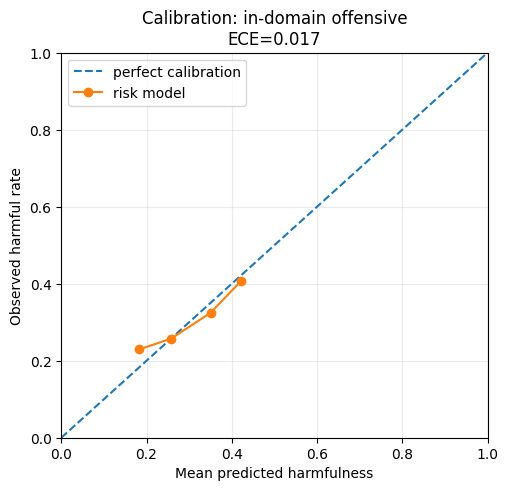

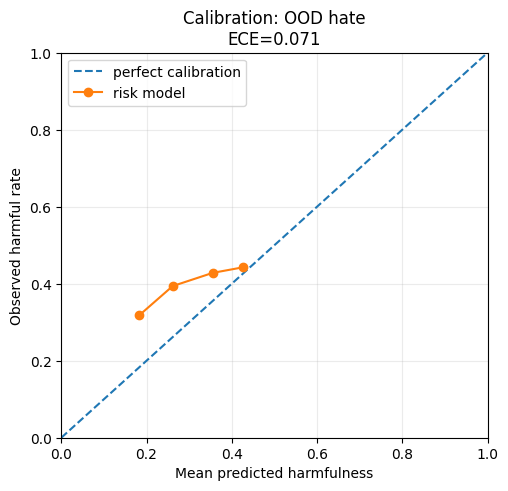

,split,ECE_10_bins,Brier,ROC_AUC,average_precision,mean_pred,empirical_rate
0,eval,0.016803,0.213498,0.575216,0.381851,0.331547,0.317
1,ood_hate,0.070608,0.250299,0.524227,0.442787,0.353392,0.424


,threshold,flagged_rate,precision,recall_tpr,false_positive_rate,false_negative_rate,accuracy
0,0.20,0.9760,0.319160,0.982650,0.972914,0.017350,0.3300
1,0.35,0.4300,0.361628,0.490536,0.401903,0.509464,0.5640
2,0.42,0.0875,0.440000,0.121451,0.071742,0.878549,0.6725
3,0.50,0.0000,0.000000,0.000000,0.000000,1.000000,0.6830
4,0.65,0.0000,0.000000,0.000000,0.000000,1.000000,0.6830
5,0.80,0.0000,0.000000,0.000000,0.000000,1.000000,0.6830


,threshold,flagged_rate,precision,recall_tpr,false_positive_rate,false_negative_rate,accuracy
0,0.20,0.989,0.425177,0.991745,0.986979,0.008255,0.428
1,0.35,0.570,0.440351,0.591981,0.553819,0.408019,0.508
2,0.42,0.159,0.443396,0.166274,0.153646,0.833726,0.558
3,0.50,0.000,0.000000,0.000000,0.000000,1.000000,0.576
4,0.65,0.000,0.000000,0.000000,0.000000,1.000000,0.576
5,0.80,0.000,0.000000,0.000000,0.000000,1.000000,0.576


In [20]:
def calibration_table(
    y_true: np.ndarray,
    p_pred: np.ndarray,
    n_bins: int = 10,
) -> pd.DataFrame:
    y_true = np.asarray(y_true, dtype=int)
    p_pred = np.clip(
        np.asarray(p_pred, dtype=float), 0.0, 1.0
    )
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_id = np.minimum(
        np.digitize(
            p_pred, edges[1:-1], right=False
        ),
        n_bins - 1,
    )

    rows = []
    for bin_index in range(n_bins):
        mask = bin_id == bin_index
        count = int(mask.sum())
        rows.append({
            "bin": bin_index,
            "lower": edges[bin_index],
            "upper": edges[bin_index + 1],
            "count": count,
            "fraction": count / max(len(y_true), 1),
            "mean_pred": (
                float(p_pred[mask].mean())
                if count else np.nan
            ),
            "empirical_rate": (
                float(y_true[mask].mean())
                if count else np.nan
            ),
        })
    return pd.DataFrame(rows)

def expected_calibration_error(
    y_true: np.ndarray,
    p_pred: np.ndarray,
    n_bins: int = 10,
) -> float:
    table = calibration_table(
        y_true, p_pred, n_bins
    )
    valid = table["count"] > 0
    return float(np.sum(
        table.loc[valid, "fraction"]
        * np.abs(
            table.loc[valid, "mean_pred"]
            - table.loc[valid, "empirical_rate"]
        )
    ))

def brier_score(
    y_true: np.ndarray,
    p_pred: np.ndarray,
) -> float:
    y_true = np.asarray(y_true, dtype=float)
    p_pred = np.asarray(p_pred, dtype=float)
    return float(np.mean((p_pred - y_true) ** 2))

def binary_roc_auc(
    y_true: np.ndarray,
    scores: np.ndarray,
) -> float:
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    n_pos = int(np.sum(y_true == 1))
    n_neg = int(np.sum(y_true == 0))
    if n_pos == 0 or n_neg == 0:
        return np.nan

    ranks = pd.Series(scores).rank(
        method="average"
    ).to_numpy()
    rank_sum_pos = ranks[y_true == 1].sum()
    auc = (
        rank_sum_pos - n_pos * (n_pos + 1) / 2
    ) / (n_pos * n_neg)
    return float(auc)

def average_precision(
    y_true: np.ndarray,
    scores: np.ndarray,
) -> float:
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    n_pos = int(np.sum(y_true == 1))
    if n_pos == 0:
        return np.nan

    order = np.argsort(-scores, kind="mergesort")
    sorted_y = y_true[order]
    cumulative_pos = np.cumsum(sorted_y)
    precision_at_k = (
        cumulative_pos
        / np.arange(1, len(sorted_y) + 1)
    )
    return float(
        np.sum(precision_at_k * sorted_y) / n_pos
    )

def plot_reliability(
    y_true: np.ndarray,
    p_pred: np.ndarray,
    title: str,
    n_bins: int = 10,
) -> pd.DataFrame:
    table = calibration_table(
        y_true, p_pred, n_bins
    )
    valid = table["count"] > 0

    plt.figure(figsize=(5.5, 5))
    plt.plot(
        [0, 1], [0, 1], "--",
        label="perfect calibration",
    )
    plt.plot(
        table.loc[valid, "mean_pred"],
        table.loc[valid, "empirical_rate"],
        marker="o",
        label="risk model",
    )
    plt.xlabel("Mean predicted harmfulness")
    plt.ylabel("Observed harmful rate")
    plt.title(
        f"{title}\n"
        f"ECE={expected_calibration_error(y_true, p_pred, n_bins):.3f}"
    )
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
    return table

eval_cal = plot_reliability(
    eval_df.label.values,
    risk_eval,
    "Calibration: in-domain offensive",
)
ood_cal = plot_reliability(
    ood_df.label.values,
    risk_ood,
    "Calibration: OOD hate",
)

risk_quality = pd.DataFrame({
    "split": ["eval", "ood_hate"],
    "ECE_10_bins": [
        expected_calibration_error(
            eval_df.label.values, risk_eval, 10
        ),
        expected_calibration_error(
            ood_df.label.values, risk_ood, 10
        ),
    ],
    "Brier": [
        brier_score(eval_df.label.values, risk_eval),
        brier_score(ood_df.label.values, risk_ood),
    ],
    "ROC_AUC": [
        binary_roc_auc(
            eval_df.label.values, risk_eval
        ),
        binary_roc_auc(
            ood_df.label.values, risk_ood
        ),
    ],
    "average_precision": [
        average_precision(
            eval_df.label.values, risk_eval
        ),
        average_precision(
            ood_df.label.values, risk_ood
        ),
    ],
    "mean_pred": [risk_eval.mean(), risk_ood.mean()],
    "empirical_rate": [
        eval_df.label.mean(), ood_df.label.mean()
    ],
})
display(risk_quality)

def risk_threshold_analysis(
    df: pd.DataFrame,
    risk_probs: np.ndarray,
    thresholds: List[float],
) -> pd.DataFrame:
    y = df.label.to_numpy(dtype=int)
    p = np.asarray(risk_probs, dtype=float)
    rows = []

    for threshold in thresholds:
        pred = p >= threshold
        tp = int(np.sum(pred & (y == 1)))
        fp = int(np.sum(pred & (y == 0)))
        tn = int(np.sum(~pred & (y == 0)))
        fn = int(np.sum(~pred & (y == 1)))

        rows.append({
            "threshold": threshold,
            "flagged_rate": float(pred.mean()),
            "precision": tp / max(tp + fp, 1),
            "recall_tpr": tp / max(tp + fn, 1),
            "false_positive_rate": fp / max(fp + tn, 1),
            "false_negative_rate": fn / max(fn + tp, 1),
            "accuracy": (
                (tp + tn) / max(len(y), 1)
            ),
        })
    return pd.DataFrame(rows)

thresholds = sorted(set([
    0.2,
    cfg.unsafe_threshold,
    cfg.extreme_unsafe_threshold,
    0.5,
    0.65,
    0.8,
]))
eval_threshold_table = risk_threshold_analysis(
    eval_df, risk_eval, thresholds
)
ood_threshold_table = risk_threshold_analysis(
    ood_df, risk_ood, thresholds
)

display(eval_threshold_table)
display(ood_threshold_table)


## 14. Final comparison and required written analysis

Now compare:

- unconstrained policies,
- safe policies,
- raw LinUCB,
- safe raw LinUCB,
- NeuralUCB-style LinUCB,
- safe NeuralUCB-style LinUCB,
- in-domain vs OOD behavior,
- calibration degradation.

### Task 14

Produce a final table and write a short explanation (here in the notebook) about it.


,policy,avg_value_eval,avg_regret_eval,harmful_allow_rate_eval,benign_block_rate_eval,allow_rate_eval,review_rate_eval,block_rate_eval,avg_value_ood,avg_regret_ood,...,allow_rate_ood,review_rate_ood,block_rate_ood,avg_value_delta_ood_minus_eval,avg_regret_delta_ood_minus_eval,harmful_allow_rate_delta_ood_minus_eval,benign_block_rate_delta_ood_minus_eval,allow_rate_delta_ood_minus_eval,review_rate_delta_ood_minus_eval,block_rate_delta_ood_minus_eval
0,oracle,0.865959,0.000000,0.000000,0.000000,0.6830,0.2880,0.029,0.820092,0.000000,...,0.5760,0.3765,0.0475,-0.045867,0.000000,0.000000,0.000000,-0.1070,0.0885,0.0185
3,ensemble_ts_mlp,0.408733,0.457226,0.134069,0.000000,0.1645,0.8355,0.000,0.412569,0.407524,...,0.1130,0.8870,0.0000,0.003836,-0.049703,-0.045626,0.000000,-0.0515,0.0515,0.0000
1,greedy_mlp,0.443640,0.422319,0.305994,0.000000,0.3845,0.6155,0.000,0.378162,0.441930,...,0.2395,0.7605,0.0000,-0.065478,0.019611,-0.085475,0.000000,-0.1450,0.1450,0.0000
2,dropout_ts_mlp,0.433321,0.432638,0.317035,0.000000,0.3810,0.6190,0.000,0.368220,0.451872,...,0.2645,0.7355,0.0000,-0.065101,0.019234,-0.067035,0.000000,-0.1165,0.1165,0.0000
4,epsilon_0.10_mlp,0.381913,0.484046,0.304416,0.040264,0.3700,0.5900,0.040,0.335719,0.484373,...,0.2435,0.7165,0.0400,-0.046194,0.000327,-0.083898,0.000535,-0.1265,0.1265,0.0000


,policy,avg_value_eval,avg_regret_eval,harmful_allow_rate_eval,benign_block_rate_eval,allow_rate_eval,review_rate_eval,block_rate_eval,avg_value_ood,avg_regret_ood,...,allow_rate_ood,review_rate_ood,block_rate_ood,avg_value_delta_ood_minus_eval,avg_regret_delta_ood_minus_eval,harmful_allow_rate_delta_ood_minus_eval,benign_block_rate_delta_ood_minus_eval,allow_rate_delta_ood_minus_eval,review_rate_delta_ood_minus_eval,block_rate_delta_ood_minus_eval
2,safe_ensemble_ts_mlp,0.408799,0.457160,0.118297,0.000000,0.1490,0.8510,0.000,0.411298,0.408795,...,0.0860,0.9140,0.000,0.002499,-0.048366,-0.048721,0.000000,-0.0630,0.0630,0.000
1,safe_dropout_ts_mlp,0.429870,0.436089,0.293375,0.000000,0.3525,0.6475,0.000,0.388407,0.431685,...,0.2150,0.7850,0.000,-0.041463,-0.004404,-0.102338,0.000000,-0.1375,0.1375,0.000
0,safe_greedy_mlp,0.439972,0.425987,0.301262,0.000000,0.3745,0.6255,0.000,0.380700,0.439392,...,0.2320,0.7680,0.000,-0.059272,0.013405,-0.088998,0.000000,-0.1425,0.1425,0.000
3,safe_epsilon_0.10_mlp,0.392149,0.473810,0.277603,0.036603,0.3510,0.6070,0.042,0.336743,0.483349,...,0.2205,0.7435,0.036,-0.055406,0.009539,-0.071235,0.000723,-0.1305,0.1365,-0.006


,policy,cum_regret,avg_regret,avg_expected_value,harmful_allow_rate,benign_block_rate,allow_rate,review_rate,block_rate
3,safe_neuralucb_last_layer,961.944794,0.480972,0.384987,0.001577,0.000732,0.0005,0.9985,0.0010
2,neuralucb_last_layer,961.944794,0.480972,0.384987,0.001577,0.000732,0.0005,0.9985,0.0010
1,safe_linucb_raw,1081.996209,0.540998,0.324961,0.189274,0.075403,0.2405,0.6820,0.0775
0,linucb_raw,1117.354406,0.558677,0.307282,0.239748,0.059297,0.2345,0.7050,0.0605


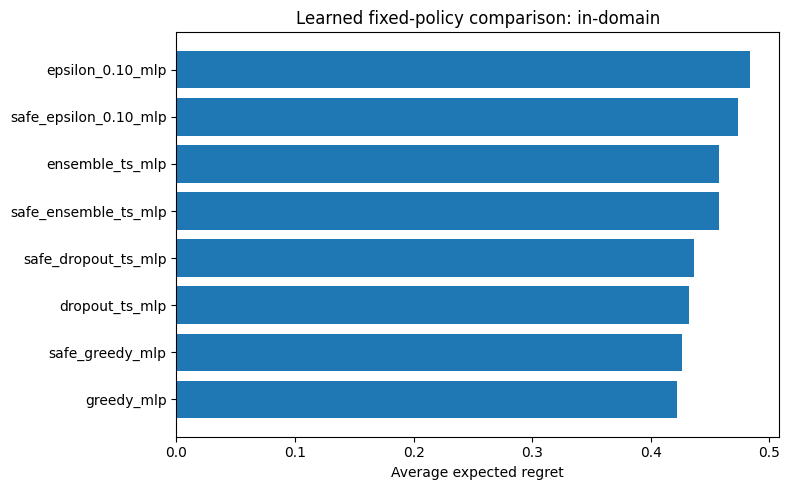

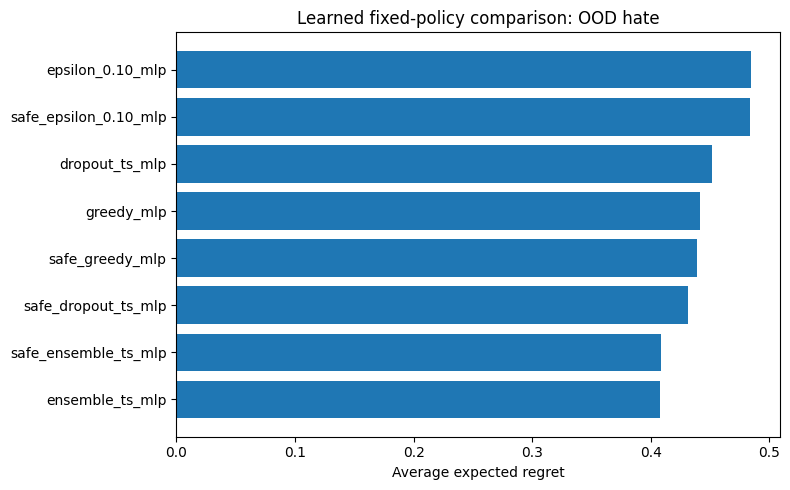

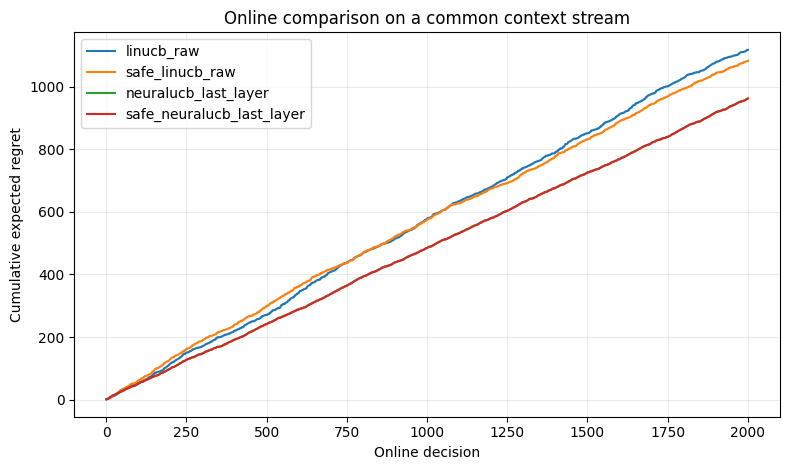

Sanity checks passed.

FINAL DATA-DEPENDENT ANALYSIS
-----------------------------
Best non-oracle fixed policy in-domain: greedy_mlp
  average regret = 0.422
  harmful-allow rate = 0.306
  review rate = 0.616

Best non-oracle fixed policy on OOD hate: ensemble_ts_mlp
  average regret = 0.408
  harmful-allow rate = 0.088
  review rate = 0.887

Best safe fixed policy in-domain: safe_greedy_mlp
  average regret = 0.426
  harmful-allow rate = 0.301
  review rate = 0.625

Lowest-regret online method(s) on the common stream:
  safe_neuralucb_last_layer: average regret=0.481, harmful-allow rate=0.002, review rate=0.999
  neuralucb_last_layer: average regret=0.481, harmful-allow rate=0.002, review rate=0.999

Risk model:
  in-domain ECE = 0.017
  OOD ECE = 0.071
  in-domain ROC-AUC = 0.575
  OOD ROC-AUC = 0.524

OOD discrimination is weak; high risk scores barely separate harmful from benign examples.

A low harmful-allow rate does not necessarily indicate strong contextual
decision making. S

In [21]:
def policy_degradation_table(
    eval_results: pd.DataFrame,
    ood_results: pd.DataFrame,
) -> pd.DataFrame:
    metrics = [
        "avg_value",
        "avg_regret",
        "harmful_allow_rate",
        "benign_block_rate",
        "allow_rate",
        "review_rate",
        "block_rate",
    ]
    left = eval_results[["policy"] + metrics].copy()
    right = ood_results[["policy"] + metrics].copy()
    out = left.merge(
        right,
        on="policy",
        suffixes=("_eval", "_ood"),
        how="inner",
    )

    for metric in metrics:
        out[f"{metric}_delta_ood_minus_eval"] = (
            out[f"{metric}_ood"]
            - out[f"{metric}_eval"]
        )
    return out.sort_values("avg_regret_ood")

def summarize_online_trace(
    trace: pd.DataFrame,
) -> Dict[str, float]:
    labels = trace.label.to_numpy(dtype=int)
    actions = trace.action.to_numpy(dtype=int)

    row = {
        "policy": trace.policy.iloc[0],
        "cum_regret": float(
            trace.cum_regret.iloc[-1]
        ),
        "avg_regret": float(trace.regret.mean()),
        "avg_expected_value": float(
            trace.expected_value.mean()
        ),
        "harmful_allow_rate": (
            float(np.mean(
                actions[labels == 1] == ALLOW
            ))
            if np.any(labels == 1) else np.nan
        ),
        "benign_block_rate": (
            float(np.mean(
                actions[labels == 0] == BLOCK
            ))
            if np.any(labels == 0) else np.nan
        ),
    }
    for action, name in enumerate(ACTIONS):
        row[f"{name}_rate"] = float(
            np.mean(actions == action)
        )
    return row

unconstrained_degradation = policy_degradation_table(
    eval_results, ood_results
)
safe_degradation = policy_degradation_table(
    safe_eval_results, safe_ood_results
)

display(unconstrained_degradation)
display(safe_degradation)

online_traces = [
    linucb_trace,
    safe_linucb_trace,
    neuralucb_trace,
    safe_neuralucb_trace,
]
online_summary = pd.DataFrame([
    summarize_online_trace(trace)
    for trace in online_traces
]).sort_values("avg_regret")
display(online_summary)

# Fixed-policy regret plots, excluding the oracle so differences among
# learned policies remain visible.
combined = pd.concat([
    eval_results.assign(
        split="in-domain", family="unconstrained"
    ),
    ood_results.assign(
        split="OOD hate", family="unconstrained"
    ),
    safe_eval_results.assign(
        split="in-domain", family="safe"
    ),
    safe_ood_results.assign(
        split="OOD hate", family="safe"
    ),
], ignore_index=True)

for split_name in ["in-domain", "OOD hate"]:
    plot_df = combined[
        (combined["split"] == split_name)
        & (combined["policy"] != "oracle")
    ].sort_values("avg_regret")

    plt.figure(figsize=(8, 5))
    plt.barh(
        plot_df["policy"],
        plot_df["avg_regret"],
    )
    plt.xlabel("Average expected regret")
    plt.title(
        f"Learned fixed-policy comparison: {split_name}"
    )
    plt.tight_layout()
    plt.show()

# Fair online comparison: all traces use the same order and noise table.
plt.figure(figsize=(8, 4.8))
for trace in online_traces:
    plt.plot(
        trace["t"],
        trace["cum_regret"],
        label=trace["policy"].iloc[0],
    )
plt.xlabel("Online decision")
plt.ylabel("Cumulative expected regret")
plt.title(
    "Online comparison on a common context stream"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Sanity checks for the RL experiment.
assert np.all(expected_regret(
    eval_df,
    oracle_action_and_value(eval_df)[0],
) >= -1e-10)
assert np.allclose(
    np.sum(
        deterministic_policy_probs(
            greedy_from_q(predict_q(
                reward_model, X_ope
            ))
        ),
        axis=1,
    ),
    1.0,
)
assert np.array_equal(
    linucb_trace.row_index.values,
    neuralucb_trace.row_index.values,
)
assert np.array_equal(
    safe_linucb_trace.row_index.values,
    safe_neuralucb_trace.row_index.values,
)
print("Sanity checks passed.")

best_eval = (
    eval_results[
        eval_results["policy"] != "oracle"
    ]
    .sort_values("avg_regret")
    .iloc[0]
)
best_ood = (
    ood_results[
        ood_results["policy"] != "oracle"
    ]
    .sort_values("avg_regret")
    .iloc[0]
)
best_safe_eval = (
    safe_eval_results
    .sort_values("avg_regret")
    .iloc[0]
)


# best_online = online_summary.iloc[0]
minimum_online_regret = online_summary["avg_regret"].min()

best_online_rows = online_summary[
    np.isclose(
        online_summary["avg_regret"],
        minimum_online_regret,
        atol=1e-10,
        rtol=0.0,
    )
]

best_online_text = "\n".join(
    (
        f"  {row.policy}: "
        f"average regret={row.avg_regret:.3f}, "
        f"harmful-allow rate={row.harmful_allow_rate:.3f}, "
        f"review rate={row.review_rate:.3f}"
    )
    for row in best_online_rows.itertuples()
)

eval_risk_row = risk_quality[
    risk_quality["split"] == "eval"
].iloc[0]
ood_risk_row = risk_quality[
    risk_quality["split"] == "ood_hate"
].iloc[0]

if ood_risk_row.ROC_AUC < 0.60:
    ood_ranking_statement = (
        "OOD discrimination is weak; high risk scores "
        "barely separate harmful from benign examples."
    )
elif ood_risk_row.ROC_AUC < 0.70:
    ood_ranking_statement = (
        "OOD discrimination is limited and should not "
        "be trusted without additional validation."
    )
else:
    ood_ranking_statement = (
        "OOD ranking remains useful, although calibration "
        "still requires separate validation."
    )

print(f"""
FINAL DATA-DEPENDENT ANALYSIS
-----------------------------
Best non-oracle fixed policy in-domain: {best_eval.policy}
  average regret = {best_eval.avg_regret:.3f}
  harmful-allow rate = {best_eval.harmful_allow_rate:.3f}
  review rate = {best_eval.review_rate:.3f}

Best non-oracle fixed policy on OOD hate: {best_ood.policy}
  average regret = {best_ood.avg_regret:.3f}
  harmful-allow rate = {best_ood.harmful_allow_rate:.3f}
  review rate = {best_ood.review_rate:.3f}

Best safe fixed policy in-domain: {best_safe_eval.policy}
  average regret = {best_safe_eval.avg_regret:.3f}
  harmful-allow rate = {best_safe_eval.harmful_allow_rate:.3f}
  review rate = {best_safe_eval.review_rate:.3f}

Lowest-regret online method(s) on the common stream:
{best_online_text}

Risk model:
  in-domain ECE = {eval_risk_row.ECE_10_bins:.3f}
  OOD ECE = {ood_risk_row.ECE_10_bins:.3f}
  in-domain ROC-AUC = {eval_risk_row.ROC_AUC:.3f}
  OOD ROC-AUC = {ood_risk_row.ROC_AUC:.3f}

{ood_ranking_statement}

A low harmful-allow rate does not necessarily indicate strong contextual
decision making. Some policies achieve it by sending nearly every example
to human review. Expected regret, safety errors, and review workload must
therefore be interpreted together.
""")

## Final discussion

### Severity proxy

The severity score is only a simple approximation. It uses the true label and a small list of risky words. Because of this, it may miss sarcasm, hidden insults, spelling changes, emojis, and context. It is useful for this experiment, but it is not a realistic moderation model.

### Cost sensitivity

The best action changes when the cost settings change. In the balanced setting, many harmful posts are sent to review. In the high-safety setting, harmful posts are mostly blocked. In the free-expression setting, review is preferred over blocking. This shows that the optimal policy depends on the goals of the platform.

### Reward model

The reward model predicts the reward of `review` much better than `allow` or `block`. Because of this, many learned policies choose review too often. Therefore, a low harmful-allow rate does not always mean that the model understands the context well. It may simply be sending most posts to human reviewers.

### Safe exploration

The safety thresholds are set to 0.35 and 0.42, so the safety mask is active. The safe policies usually allow fewer harmful posts, but they also send more posts to review and may block more benign posts. This shows the trade-off between safety and moderation cost.

### Online policies

NeuralUCB has lower regret than raw LinUCB. However, it chooses `review` for almost every example. This makes it safer, but it also creates a very large human-review workload. The safe and normal NeuralUCB results are almost the same because the normal policy is already very conservative.

### Offline policy evaluation

IPS, SNIPS, Direct Method, and Doubly Robust estimation were tested on held-out logged data. SNIPS gave the smallest error in this experiment. The Direct Method was affected by errors in the reward model, while IPS had more variance because of importance weights. Doubly Robust estimation gave reasonable results and its confidence intervals included the true values.

### Calibration and OOD results

The risk model is well calibrated on the in-domain data, with a small ECE. However, its ROC-AUC is low, so it is not very good at separating harmful and benign posts.

On the OOD hate dataset, both calibration and discrimination become worse. The model also underestimates the amount of harmful content. This shows that a model trained on offensive-language data may not work well on a different moderation task.

### Conclusion

The results show that regret alone is not enough to evaluate a moderation policy. We also need to consider harmful-allow rate, benign-block rate, review workload, calibration, and OOD performance.

The safe policies reduce some harmful decisions, but they depend strongly on the quality of the risk model. The current models are useful for demonstrating the contextual-bandit methods in this project, but they are not accurate enough for real deployment.


## Analysis Components

- Real dataset loading, EDA, severity critique
- Reward, oracle, regret
- cost-sensitivity analysis
- Logged bandit feedback and propensities
- Reward model from chosen-action feedback
- Fixed policies and uncertainty policies
- safe exploration
- Raw LinUCB
- NeuralUCB-style LinUCB
- Offline policy evaluation
- calibration analysis
- OOD stress analysis
- Final safety/product discussion


## Answers to the Experimental Questions

### 1. Dataset

**(a) What are the limitations of using binary labels as reward ground truth?**

Binary labels only show whether a post is harmful or benign. They do not represent severity, uncertainty, review cost, or the different consequences of allowing, reviewing, and blocking a post. They may also contain annotation errors and disagreements.

**(b) Why is `tweet_eval/hate` a reasonable but imperfect OOD stress test for `tweet_eval/offensive`?**

Both datasets contain tweets and are related to content moderation, so hate speech is a useful distribution shift. However, hate speech and offensive language have different definitions, vocabulary, label distributions, and examples. Therefore, it is not a perfect representation of every real-world OOD shift.

---

### 2. Severity Proxy

**(a) Why is the severity proxy dangerous if treated as ground truth?**

The severity score is based on a simple heuristic and the true binary label. It may miss context, sarcasm, hidden insults, spelling changes, and implicit harm. Therefore, it should only be used as a simulator variable, not as a real measure of severity.

**(b) What signals does it overemphasize?**

It overemphasizes surface-level signals such as risky keywords, capital letters, exclamation marks, direct mentions, and short negative phrases.

---

### 3. Reward, Oracle, Regret, and Cost Sensitivity

**(a) Which product profile is most likely to over-block?**

The `high_safety` profile is most likely to over-block because it gives a large penalty for allowing harmful content and a relatively high reward for blocking it.

**(b) Why is this a bandit problem rather than a standard classification problem?**

The system selects an action and observes only the reward of that chosen action. It does not observe the rewards of the other actions. It must also balance exploration and exploitation, which is not required in normal supervised classification.

**(c) Why does the oracle action distribution change across profiles?**

Each profile assigns different costs and rewards to allowing, reviewing, and blocking. Therefore, the action with the highest expected reward can change even for the same post.

---

### 4. Logged Bandit Data

**(a) How might low propensities affect offline policy evaluation?**

Low propensities create large importance weights. This increases estimator variance, reduces the effective sample size, and can make IPS, SNIPS, and DR estimates unstable.

---

### 5. Risk Model for Safety and Calibration

**(a) Is it fair to use labels here while the reward model uses bandit feedback?**

Yes, if the labels come from a separate supervised source such as human audits or historical moderation data. However, the risk model then uses stronger supervision than the reward model, so this difference should be clearly stated.

**(b) What would change if labels were delayed or missing?**

Risk-model training would become slower and possibly biased. The system might need delayed-feedback methods, periodic human audits, semi-supervised learning, or confidence-based safety rules.

---

### 6. Fixed Policies from the Reward Model

**(a) Does uncertainty help?**

Uncertainty can help by exploring actions whose rewards are not well known and by preventing the policy from committing too early. However, exploration must be limited by safety constraints.

**(b) Which policy has the highest block rate?**

In the in-domain fixed-policy results, `safe_epsilon_0.10_mlp` has the highest block rate, about **4.2%**. Among the unconstrained policies, `epsilon_0.10_mlp` has the highest block rate, about **4.0%**.

**(c) Which policy has the worst OOD degradation?**

`greedy_mlp` has the largest increase in average regret on the OOD data, about **0.020**. Its average value also decreases by about **0.065**.

---

### 7. Safe Exploration Constraints

**(a) What is an ethically acceptable exploration space for content moderation?**

Exploration should only occur among actions allowed by the safety rules. High-risk content should not be randomly allowed. Uncertain or risky examples should mainly be explored between review and block, while low-risk examples may allow wider exploration.

---

### 8. Online LinUCB

**(a) Why can LinUCB be more stable than neural Thompson sampling during the early stages of learning?**

LinUCB uses a simple linear model, regularization, and an explicit confidence bonus. It has fewer parameters and can update its uncertainty directly. Neural Thompson sampling has more parameters and may produce unreliable uncertainty estimates when little data is available.

---

### 9. Offline Policy Evaluation

**(a) Which estimator is most variable?**

IPS is usually the most variable because it directly uses importance weights, which can become very large.

**(b) Which estimator is most biased when the reward model is poor?**

The Direct Method is usually the most biased because it depends entirely on the reward model’s predictions.

**(c) What happens when target actions have very low behavior propensities?**

Importance weights become large, variance increases, and the effective sample size decreases. As a result, IPS, SNIPS, and DR estimates become less reliable.

---

### 10. Calibration

**(a) How does miscalibration affect safe exploration?**

If risk is underestimated, harmful posts may be allowed because they do not pass the safety threshold. If risk is overestimated, too many benign posts may be reviewed or blocked. Therefore, poorly calibrated probabilities make safety thresholds unreliable.
